In [38]:
import pymcel as pc
import rebound as rb
import numpy as np
import matplotlib.pyplot as plt
from celluloid import Camera
from IPython.display import HTML, display
import plotly.graph_objects as go
import spiceypy as spy

In [39]:
T = 5033862 # canonical time unit in seconds
seconds_in_four_years = 4 * 365.25 * 24 * 3600

four_years_in_canon = (seconds_in_four_years / T)
print(f"Four years in canon time units is: {four_years_in_canon}")

Four years in canon time units is: 25.076253580253095


In [40]:
rb.horizons.SSL_CONTEXT = 'unverified'

In [41]:
sim = rb.Simulation()
date0 = '2010-01-01'

bodies = [
    ('Saturn', '699'),
    ('Janus', '610'),
    ('Epimetheus', '611'),
    ('Prometheus', '616'),
    ("Pandora", '617'),
    ("Mimas", '601')
]

for label, target in bodies:
    print(f"Adding {label} to the simulation.")
    sim.add(target, date=date0)

Adding Saturn to the simulation.
Searching NASA Horizons for '699'... 
Found: Saturn (699) 
Adding Janus to the simulation.
Searching NASA Horizons for '610'... 
Found: Janus (610) 
Adding Epimetheus to the simulation.
Searching NASA Horizons for '611'... 
Found: Epimetheus (611) 
Adding Prometheus to the simulation.
Searching NASA Horizons for '616'... 
Found: Prometheus (616) 
Adding Pandora to the simulation.
Searching NASA Horizons for '617'... 
Found: Pandora (617) 
Adding Mimas to the simulation.
Searching NASA Horizons for '601'... 
Found: Mimas (601) 


In [42]:
sim.status()

---------------------------------
REBOUND version:     	4.6.0
REBOUND built on:    	Feb 11 2026 17:44:35
Number of particles: 	6
Selected integrator: 	ias15
Simulation time:     	0.0000000000000000e+00
Current timestep:    	0.001000
---------------------------------
<rebound.particle.Particle object at 0x1f818e148d0, m=0.00028581500081698117 x=-9.46800446342915 y=0.26161067842824864 z=0.37221506693439704 vx=-0.02628140499999831 vy=-0.3248583414628617 vz=0.00667892483969261>
<rebound.particle.Particle object at 0x1f818e14c50, m=9.537652224706244e-13 x=-9.467918441516842 y=0.2607178179389588 z=0.37267141591369773 vx=0.5053524442152856 vy=-0.3074699298167483 vz=-0.054206885978828744>
<rebound.particle.Particle object at 0x1f818e148d0, m=2.646574267716062e-13 x=-9.467823933377128 y=0.26072258494212475 z=0.3726578709461376 vx=0.49634974037559293 vy=-0.2576805380203303 vz=-0.08167533827266592>
<rebound.particle.Particle object at 0x1f818e14c50, m=8.101787599322461e-14 x=-9.467341680780482 y=

In [43]:
N = len(sim.particles)

In [44]:
ts = np.linspace(0, four_years_in_canon*4,1000)
rps = np.zeros((N, 1000, 3))
vps = np.zeros((N, 1000, 3))

for i, t in enumerate(ts):
    sim.integrate(t)
    sim.move_to_com()
    for j in range(N):
        rps[j, i] = sim.particles[j].xyz
        vps[j, i] = sim.particles[j].vxyz

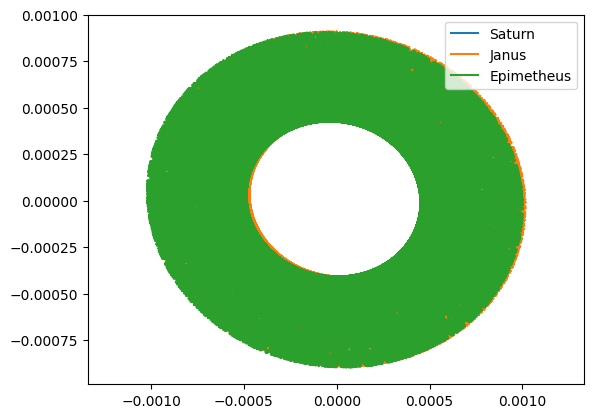

In [45]:
plt.plot(rps[0,:,0], rps[0,:,1], label='Saturn')
plt.plot(rps[1,:,0], rps[1,:,1], label='Janus')
plt.plot(rps[2,:,0], rps[2,:,1], label='Epimetheus')
plt.legend()
plt.axis('equal')
plt.show()


In [46]:
def animar_sistema_2d(rs, ts):
 fig, ax = plt.subplots(figsize=(6, 6))
 camera = Camera(fig)

 # Limit the animation to Apophis through Jupiter.
 n_particles = min(8, rs.shape[0])
 rs = rs[:n_particles]

 # Fondo del grafico (una sola vez).
 ax.set_aspect('equal', adjustable='box')
 ax.grid(alpha=0.3)

 # Menos cuadros => render mas rapido.
 step = 10
 colors = plt.cm.viridis(np.linspace(0, 1, n_particles))

 for i in range(0, len(ts), step):
    for p in range(n_particles):
        # Resaltar el cuerpo central (indice 0).
        lw = 1.2 if p == 0 else 0.8
        alpha = 0.35 if p == 0 else 0.2
        ms = 7 if p == 0 else 3

        ax.plot(rs[p, :, 0], rs[p, :, 1], '-', color=colors[p], lw=lw, alpha=alpha)
        ax.plot(rs[p, i, 0], rs[p, i, 1], 'o', color=colors[p], ms=ms)

    camera.snap()

 anim = camera.animate(interval=60, blit=False)
 #anim.save("my_animation.gif", writer="pillow", fps=20)
 plt.close(fig)

 return HTML(anim.to_jshtml())

In [47]:
# animar_sistema_2d(rps, ts)

In [48]:
def anima_ncuerpos(masas, rps, T):
    N = rps.shape[0]
    Nt = rps.shape[1]
    T_total = Nt * (T / Nt)  # tiempo total de la simulación
    
    # Colores de las partículas
    colors_hex = [f'hsl({int(j/N*360)},70%,50%)' for j in range(N)]

    # Submuestreo para que la animación sea fluida pero no pesada
    n_frames = 120
    idx = np.linspace(0, Nt - 1, n_frames, dtype=int)
    s_markers = [min(30, max(4, int(masas[j] * 120 + 4))) for j in range(N)]

    base_traces = []
    for j in range(N):
        base_traces.append(go.Scatter3d(
            x=rps[j, :, 0], y=rps[j, :, 1], z=rps[j, :, 2],
            mode='lines',
            line=dict(color=colors_hex[j], width=1),
            opacity=0.25,
            showlegend=False,
            hoverinfo='skip'
        ))

    # Posiciones iniciales de los cuerpos (frame 0)
    for j in range(N):
        base_traces.append(go.Scatter3d(
            x=[rps[j, idx[0], 0]],
            y=[rps[j, idx[0], 1]],
            z=[rps[j, idx[0], 2]],
            mode='markers',
            marker=dict(color=colors_hex[j], size=s_markers[j],
                        line=dict(color='black', width=0.5)),
            name=f'Cuerpo {j+1}',
            showlegend=False
        ))

    frames = []
    for fi, ki in enumerate(idx):
        frame_data = []
        # Las N primeras trazas son trayectorias (no cambian); actualizamos sólo las N de puntos
        for j in range(N):
            frame_data.append(go.Scatter3d(
                x=[rps[j, ki, 0]],
                y=[rps[j, ki, 1]],
                z=[rps[j, ki, 2]],
            ))
        frames.append(go.Frame(
            data=frame_data,
            traces=list(range(N, 2 * N)),   # índices de las trazas de puntos
            name=str(fi)
        ))

    fig_anim = go.Figure(data=base_traces, frames=frames)
    fig_anim.update_layout(
        title=dict(
            text=f'Animación 3D — {N} cuerpos — T = {T_total} u.t.c.',
            x=0.5
        ),
        scene=dict(
            xaxis_title='x [u.c.]',
            yaxis_title='y [u.c.]',
            zaxis_title='z [u.c.]',
            aspectmode='data'
        ),
        width=860, height=760,
        margin=dict(l=0, r=0, b=0, t=50),
        updatemenus=[dict(
            type='buttons',
            showactive=False,
            y=0.02, x=0.5, xanchor='center',
            buttons=[
                dict(label='▶ Play',
                    method='animate',
                    args=[None, dict(frame=dict(duration=40, redraw=True),
                                    fromcurrent=True, mode='immediate')]),
                dict(label='⏸ Pausa',
                    method='animate',
                    args=[[None], dict(frame=dict(duration=0, redraw=False),
                                        mode='immediate')])
            ]
        )],
        sliders=[dict(
            currentvalue=dict(prefix='Frame: ', visible=True, xanchor='center'),
            pad=dict(t=40),
            steps=[dict(method='animate',
                        args=[[str(fi)], dict(mode='immediate',
                                            frame=dict(duration=0, redraw=True))],
                        label=str(fi))
                for fi in range(n_frames)]
        )]
    )
    fig_anim.show()

In [49]:
# masas = [sim.particles[i].m for i in range(N)]
# anima_ncuerpos(masas, rps, T=four_years_in_canon)

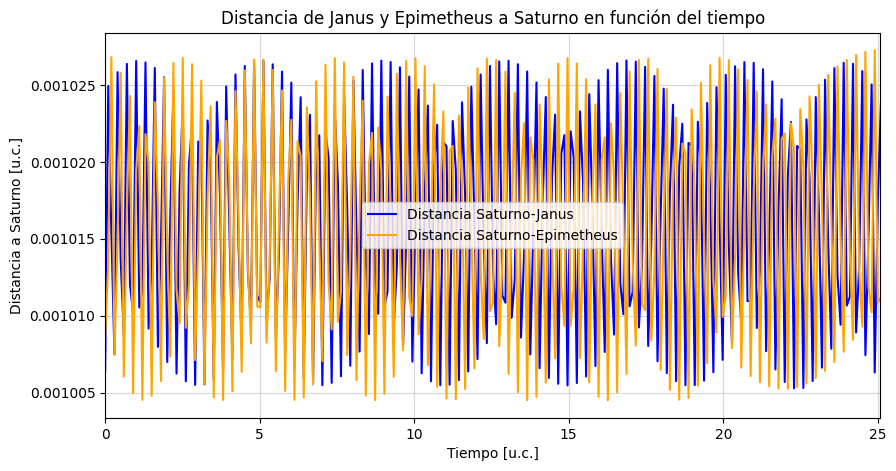

In [50]:
# Calculamos las distancias de las lunas a Saturno en cada instante de tiempo
d_janus = np.linalg.norm(rps[1, :, :] - rps[0, :, :], axis=1)
d_epimetheus = np.linalg.norm(rps[2, :, :] - rps[0, :, :], axis=1)

# Graficamos
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ts, d_janus, label='Distancia Saturno-Janus', color='blue')
ax.plot(ts, d_epimetheus, label='Distancia Saturno-Epimetheus', color='orange')

# Limit plotting range to the first 4 years in canonical units
ax.set_xlim(0, four_years_in_canon)

ax.set_xlabel('Tiempo [u.c.]')
ax.set_ylabel('Distancia a Saturno [u.c.]')
ax.set_title('Distancia de Janus y Epimetheus a Saturno en función del tiempo')
ax.legend()
ax.grid(alpha=0.5)

plt.show()

In [51]:
# Un año en unidades de tiempo canónicas
one_year_canon = four_years_in_canon / 4

# Lista para guardar los estados de las lunas cada año
yearly_states = []

for year in range(17): # 0 a 16 años
    target_t = year * one_year_canon
    # Encontramos el índice en 'ts' más cercano a 'target_t'
    idx = np.argmin(np.abs(ts - target_t))
    
    state = {
        'year': year,
        'time_canon': ts[idx],
        'saturn_pos': rps[0, idx, :],
        'saturn_vel': vps[0, idx, :],
        'janus_pos': rps[1, idx, :],
        'janus_vel': vps[1, idx, :],
        'epimetheus_pos': rps[2, idx, :],
        'epimetheus_vel': vps[2, idx, :]
    }
    yearly_states.append(state)

# Imprimimos los resultados para los primeros 3 años a modo de prueba
for s in yearly_states[:3]:
    print(f"--- Año {s['year']} ---")
    print(f"Saturn Pos: {s['saturn_pos']}")
    print(f"Janus Pos: {s['janus_pos']}")
    print(f"Epimetheus Pos: {s['epimetheus_pos']}\n")

--- Año 0 ---
Saturn Pos: [ 7.59232677e-11 -2.74599787e-11  9.61264401e-12]
Janus Pos: [ 8.60219882e-05 -8.92860517e-04  4.56348989e-04]
Epimetheus Pos: [ 0.00018053 -0.00088809  0.0004428 ]

--- Año 1 ---
Saturn Pos: [ 7.95136290e-11 -1.03541953e-11  2.57529104e-13]
Janus Pos: [ 9.86987515e-04 -2.44693617e-04  3.11340619e-05]
Epimetheus Pos: [-1.43764790e-05  9.06910010e-04 -4.69540292e-04]

--- Año 2 ---
Saturn Pos: [ 3.25808781e-11  6.58520157e-11 -3.74588993e-11]
Janus Pos: [-1.00662136e-03  1.03158040e-04  4.44391742e-05]
Epimetheus Pos: [ 0.00083055  0.00047221 -0.00033017]



In [52]:
spy.oscelt?

Signature: spy.oscelt(state: numpy.ndarray, et: float, mu: Union[float, int]) -> numpy.ndarray
Docstring:
Determine the set of osculating conic orbital elements that
corresponds to the state (position, velocity) of a body at
some epoch.

https://naif.jpl.nasa.gov/pub/naif/misc/toolkit_docs_N0067/C/cspice/oscelt_c.html

:param state: State of body at epoch of elements.
:param et: Epoch of elements in ephemeris seconds past J2000.
:param mu: Gravitational parameter (GM) of primary body in km**3/sec**2 units.
:return: Equivalent conic elements in  km, rad, rad/sec units.
File:      c:\users\jaide\onedrive\documentos\visual_projects\meccel-20261\meccelenv312\lib\site-packages\spiceypy\spiceypy.py
Type:      function

In [53]:
#Listas para almacenar los elementos orbitales a lo largo del tiempo para Janus

q_s_j = [] #periapsis
e_s_j = [] #excentricidad
i_s_j = [] #inclinación
Omega_s_j = [] #longitud del nodo ascendente
omega_s_j = [] #argumento del periastro
M_s_j = [] #anomalía media
tp_s_j = [] #tiempo de paso por el periastro
mu_s_j = [] #parámetro gravitacional
a_s_j = [] #semieje mayor

#Lista para almacenar los elementos orbitales a lo largo del tiempo para Epimetheus

q_s_e = [] #periapsis
e_s_e = [] #excentricidad
i_s_e = [] #inclinación
Omega_s_e = [] #longitud del nodo ascendente
omega_s_e = [] #argumento del periastro
M_s_e = [] #anomalía media
tp_s_e = [] #tiempo de paso por el periastro
mu_s_e = [] #parámetro gravitacional
a_s_e = [] #semieje mayor

# Definimos factores de conversión
AU_in_km = 149597870.7  # 1 AU en kilómetros
V_canon_to_kms = AU_in_km / T  # Conversión de velocidad de c.u. a km/s

mu_saturn_km = pc.constantes.mu_saturn * 1e-9

for i in range(len(yearly_states)):
    # spiceypy DEBE recibir el vector de estado RELATIVO al cuerpo central (Saturno).
    # Como los datos fueron integrados y salvados alrededor del baricentro del sistema, 
    # restamos la posición y velocidad de Saturno.
    pos_j_rel = (yearly_states[i]['janus_pos'] - yearly_states[i]['saturn_pos']) * AU_in_km
    vel_j_rel = (yearly_states[i]['janus_vel'] - yearly_states[i]['saturn_vel']) * V_canon_to_kms

    state_vector = np.concatenate((pos_j_rel, vel_j_rel))
    et_time = yearly_states[i]['time_canon'] * T  # Mantenemos el tiempo en segundos
    
    oscelt_result = spy.oscelt(state=state_vector, et=et_time, mu=mu_saturn_km)
    
    q_s_j.append(oscelt_result[0])
    e_s_j.append(oscelt_result[1])
    i_s_j.append(oscelt_result[2])
    Omega_s_j.append(oscelt_result[3])
    omega_s_j.append(oscelt_result[4])
    M_s_j.append(oscelt_result[5])
    tp_s_j.append(oscelt_result[6])
    mu_s_j.append(oscelt_result[7])

    a_j = oscelt_result[0] / (1 - oscelt_result[1])  # Semieje mayor = q / (1 - e)
    a_s_j.append(a_j) 

    # Conversión para Epimetheus (también restando a Saturno para obtener estado relativo)
    pos_e_rel = (yearly_states[i]['epimetheus_pos'] - yearly_states[i]['saturn_pos']) * AU_in_km
    vel_e_rel = (yearly_states[i]['epimetheus_vel'] - yearly_states[i]['saturn_vel']) * V_canon_to_kms
    state_vector_e = np.concatenate((pos_e_rel, vel_e_rel))
    
    oscelt_result_e = spy.oscelt(state=state_vector_e, et=et_time, mu=mu_saturn_km)
    
    q_s_e.append(oscelt_result_e[0])
    e_s_e.append(oscelt_result_e[1])
    i_s_e.append(oscelt_result_e[2])
    Omega_s_e.append(oscelt_result_e[3])
    omega_s_e.append(oscelt_result_e[4])
    M_s_e.append(oscelt_result_e[5])
    tp_s_e.append(oscelt_result_e[6])
    mu_s_e.append(oscelt_result_e[7])

    a_e = oscelt_result_e[0] / (1 - oscelt_result_e[1])  # Semieje mayor = q / (1 - e)
    a_s_e.append(a_e)


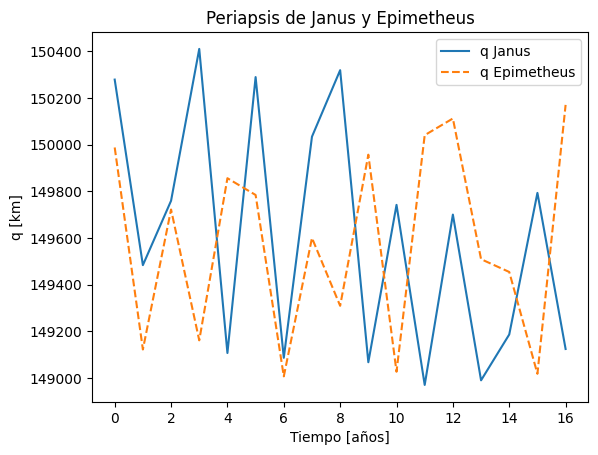

In [99]:
plt.plot(np.arange(len(q_s_j)), q_s_j, label='q Janus')
plt.plot(np.arange(len(q_s_e)), q_s_e, label='q Epimetheus', linestyle='--')
plt.xlabel('Tiempo [años]')
plt.ylabel('q [km]')
plt.title('Periapsis de Janus y Epimetheus')
plt.legend()
plt.show()

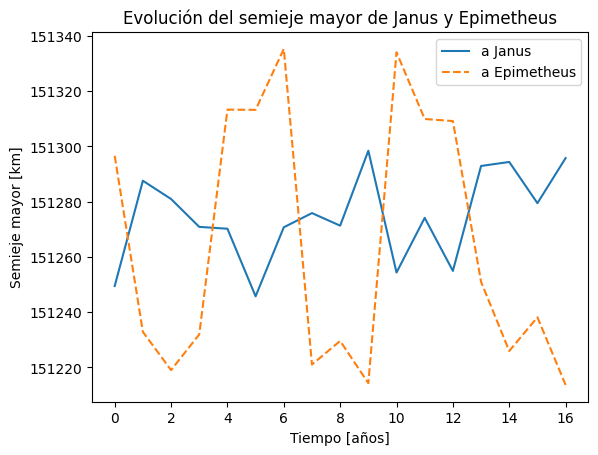

In [54]:
plt.plot(np.arange(len(a_s_j)), a_s_j, label='a Janus')
plt.plot(np.arange(len(a_s_e)), a_s_e, label='a Epimetheus', linestyle='--')
plt.xlabel('Tiempo [años]')
plt.ylabel('Semieje mayor [km]')
plt.title('Evolución del semieje mayor de Janus y Epimetheus')
plt.legend()
plt.show()

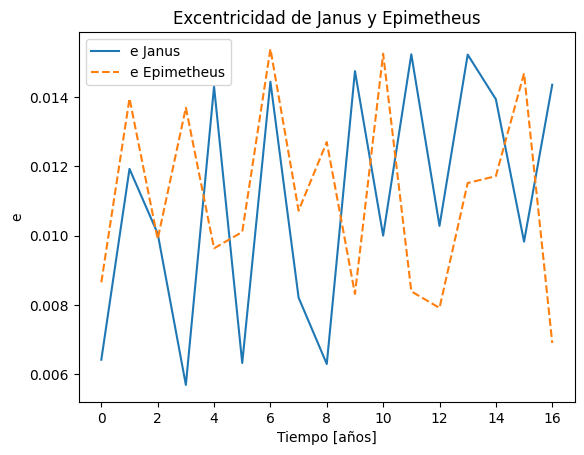

In [55]:
plt.plot(np.arange(len(e_s_j)), e_s_j, label='e Janus')
plt.plot(np.arange(len(e_s_e)), e_s_e, label='e Epimetheus', linestyle='--')
plt.xlabel('Tiempo [años]')
plt.ylabel('e')
plt.title('Excentricidad de Janus y Epimetheus')
plt.legend()
plt.show()

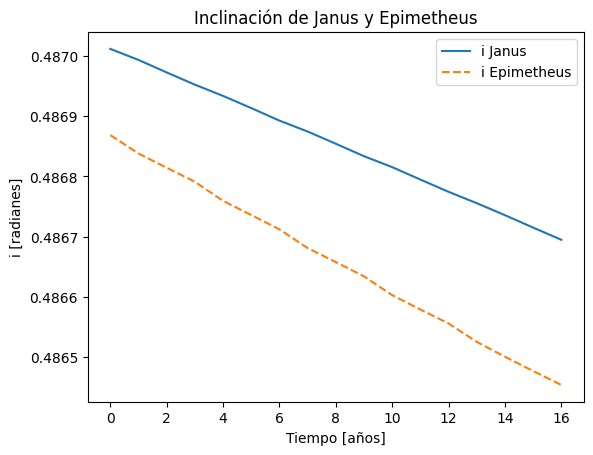

In [56]:
plt.plot(np.arange(len(i_s_j)), i_s_j, label='i Janus')
plt.plot(np.arange(len(i_s_e)), i_s_e, label='i Epimetheus', linestyle='--')
plt.xlabel('Tiempo [años]')
plt.ylabel('i [radianes]')
plt.title('Inclinación de Janus y Epimetheus')
plt.legend()
plt.show()

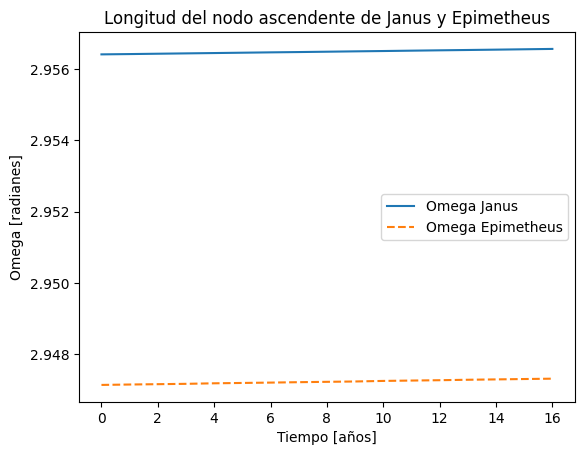

In [57]:
plt.plot(np.arange(len(Omega_s_j)), Omega_s_j, label='Omega Janus')
plt.plot(np.arange(len(Omega_s_e)), Omega_s_e, label='Omega Epimetheus', linestyle='--')
plt.xlabel('Tiempo [años]')
plt.ylabel('Omega [radianes]')
plt.title('Longitud del nodo ascendente de Janus y Epimetheus')
plt.legend()
plt.show()

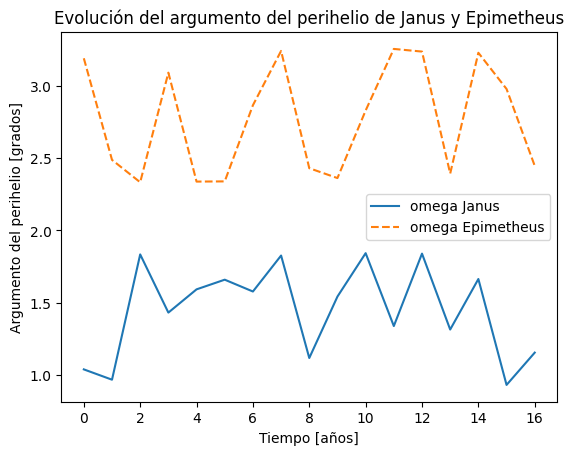

In [58]:
plt.plot(np.arange(len(omega_s_j)), omega_s_j, label='omega Janus')
plt.plot(np.arange(len(omega_s_e)), omega_s_e, label='omega Epimetheus', linestyle='--')
plt.xlabel('Tiempo [años]')
plt.ylabel('Argumento del perihelio [grados]')
plt.title('Evolución del argumento del perihelio de Janus y Epimetheus')
plt.legend()
plt.show()